Study the convergence for different values of curvature

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import xtrack as xt
import bpmeth
import sympy as sp
import pandas as pd
from scipy.interpolate import PchipInterpolator

b1 commands curvature here

curvature h[m^-1]:  0.01 radius of curvature [m]:  100.0
E [GeV]:  1.03827208816
beta0:  0.42819548497881543
xinit= [-0.05  -0.025  0.     0.025  0.05 ]
nphi= 5


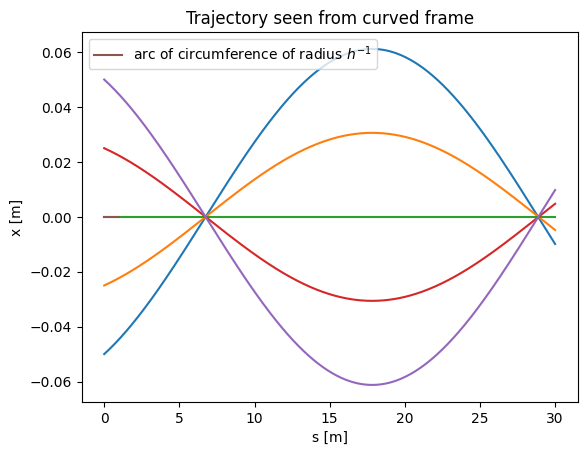

In [ ]:
a_curved = [0,]
b_curved = [10, 0.02]
h= b_curved[0]# considering normalization B/Brho=1/rho=h            =1. if checking for a drift
print("curvature h[m^-1]: ", h, "radius of curvature [m]: ", 1/h)
#I want to track protons of given kinetic energy
Ek=1e8 #eV
p=np.sqrt(Ek**2+2*Ek*xt.PROTON_MASS_EV)#momentum eV/c
Eref = Ek + xt.PROTON_MASS_EV
print("E [GeV]: ", Eref/1e9)
gamma0 = Eref/xt.PROTON_MASS_EV
beta0 = np.sqrt(1-1/gamma0**2)
print("beta0: ", beta0)
#hx_max=5e-4 #maximum modulus of product of h and x between for initial conditions, to avoid the singularity in the vector potential
xinit=np.linspace(-1e-3, 1e3, 5)
print("xinit=",xinit)
p0 =xt.Particles(x=xinit, y=0, s=0, py=np.linspace(0.005,-0.005,5), px=np.linspace(0.005,-0.005,5), ptau=0, beta0=beta0, energy0=Eref, mass0=xt.PROTON_MASS_EV)
p_1 = p0.copy()
nphi=5 #default is 5
print("nphi=",nphi)
A_curved= bpmeth.GeneralVectorPotential(h=h, b=b_curved, a=a_curved, nphi=nphi)
bending_angle=0.3#rad, fix for all the tests
fixedlength=bending_angle/h
H_curved = bpmeth.Hamiltonian(length=fixedlength, h=h, vectp=A_curved)

sol_curved = H_curved.track(p_1, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})

for ss in sol_curved:
    plt.plot(ss.t, ss.y[0])
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("Trajectory seen from curved frame")
x=np.linspace(0,1,50)
y= np.zeros_like(x)
plt.plot(x,y, label='arc of circumference of radius $h^{-1}$')
plt.legend()
plt.show()

In [31]:
expansion_curved = bpmeth.FieldExpansion(a=a_curved, b=b_curved, h=h, nphi=5)#, nphi=nphi)
phi_curved = expansion_curved.get_phi()
print("phi curved frame: ", phi_curved)
#transform the scalar potential to curved frame using coordinate transformations
#xcurved =sqrt((x+rho)**2+s**2)-rho       scurved=rho*arctan(s/(x+rho))   with rho=1/h
x, y, s = sp.symbols('x y s', real=True)
xtmp, stmp = sp.symbols("xtmp stmp", real=True)
# rename the curved coordinates temporarily
phi_tmp = phi_curved.xreplace({
    x: xtmp,
    s: stmp
})
# substitute curved -> straight
phi_straight = phi_tmp.xreplace({
    xtmp: sp.sqrt((x + 1/h)**2 + s**2) - 1/h,
    stmp: 1/h * sp.atan(s/(x + 1/h))
})
print("\nphi straight frame: ", phi_straight)

Bxstraight_ana = -phi_straight.diff(x)
Bystraight_ana = -phi_straight.diff(y)
Bsstraight_ana = -phi_straight.diff(s)
print("\nBx straight frame: ", Bxstraight_ana)

phi curved frame:  (y**3*(2.0e-6*x + 0.0002)*(2.4e-7*x**4 + 9.6e-5*x**3 + 0.0144*x**2 + 0.96*x + 24.0) - 6*y*(0.01*x + 1)**2*(0.02*x + 0.01)*(2.4e-7*x**4 + 9.6e-5*x**3 + 0.0144*x**2 + 0.96*x + 24.0))/(6*(0.01*x + 1)**2*(2.4e-7*x**4 + 9.6e-5*x**3 + 0.0144*x**2 + 0.96*x + 24.0))

phi straight frame:  1666.66666666667*(y**3*(2.0e-6*sqrt(s**2 + (x + 100.0)**2) - 2.71050543121376e-20)*(0.96*sqrt(s**2 + (x + 100.0)**2) + 2.4e-7*(sqrt(s**2 + (x + 100.0)**2) - 100.0)**4 + 9.6e-5*(sqrt(s**2 + (x + 100.0)**2) - 100.0)**3 + 0.0144*(sqrt(s**2 + (x + 100.0)**2) - 100.0)**2 - 72.0) - 6*y*(0.0001*s**2 + 0.0001*(x + 100.0)**2)*(0.02*sqrt(s**2 + (x + 100.0)**2) - 1.99)*(0.96*sqrt(s**2 + (x + 100.0)**2) + 2.4e-7*(sqrt(s**2 + (x + 100.0)**2) - 100.0)**4 + 9.6e-5*(sqrt(s**2 + (x + 100.0)**2) - 100.0)**3 + 0.0144*(sqrt(s**2 + (x + 100.0)**2) - 100.0)**2 - 72.0))/((s**2 + (x + 100.0)**2)*(0.96*sqrt(s**2 + (x + 100.0)**2) + 2.4e-7*(sqrt(s**2 + (x + 100.0)**2) - 100.0)**4 + 9.6e-5*(sqrt(s**2 + (x + 100.0)**2)

## Full callable function

In [32]:
def compute_rms_for_order(maxordx, sol_strfromphi, sol_curved, Lstr, make_particle_plots=False):


    dx_exit_list = []
    rms_x_list = []

    for i, (sb, sa) in enumerate(zip(sol_strfromphi, sol_curved)):
        sbar_str = sb.t
        xbar_str = sb.y[0]

        s_curv = sa.t
        x_curv = sa.y[0]

        sbar_from_curv = (rho + x_curv) * np.sin(s_curv / rho)
        xbar_from_curv = -rho + (rho + x_curv) * np.cos(s_curv / rho)

        sbar_min = max(sbar_str.min(), sbar_from_curv.min())
        sbar_max = min(sbar_str.max(), sbar_from_curv.max())

        if sbar_max <= sbar_min:
            print(f"particle {i}: no overlap in sbar range, skipping")
            continue

        sbar_common = np.linspace(sbar_min, sbar_max, 500)

        xbar_str_common = PchipInterpolator(sbar_str, xbar_str)(sbar_common)

        idx_curv = np.argsort(sbar_from_curv)
        sbar_sorted = sbar_from_curv[idx_curv]
        xbar_sorted = xbar_from_curv[idx_curv]

        xbar_curv_common = PchipInterpolator(sbar_sorted, xbar_sorted)(sbar_common)

        dx_all = xbar_str_common - xbar_curv_common
        rms_x = np.sqrt(np.mean(dx_all**2))
        rms_x_list.append(rms_x)

        xbar_exit_straight = np.interp(sbar_fin, sbar_str, xbar_str)
        xbar_exit_from_curv = np.interp(sbar_fin, sbar_sorted, xbar_sorted)

        dx_exit = xbar_exit_straight - xbar_exit_from_curv
        dx_exit_list.append(dx_exit)

        print(
            f"[order {maxordx}] particle {i}: "
            f"dx_exit = {dx_exit:.3e} m, RMS_x = {rms_x:.3e} m"
        )

    mean_dx_exit = np.mean(dx_exit_list) if dx_exit_list else np.nan
    mean_rms_x = np.mean(rms_x_list) if rms_x_list else np.nan

    if make_particle_plots:
        plt.figure()
        plt.plot(range(len(dx_exit_list)), dx_exit_list, "o")
        plt.xlabel("particle index")
        plt.ylabel(r"$\Delta x_{\mathrm{exit}}$ [m]")
        plt.title(
            "Difference at exit using "
            + r"$\phi$ transformation of order "
            + str(maxordx)
        )
        plt.grid(True)

        plt.figure()
        plt.plot(range(len(rms_x_list)), rms_x_list, "o")
        plt.xlabel("particle index")
        plt.ylabel(r"RMS$_x$ over magnet [m]")
        plt.title(
            "RMS difference in x along magnet using "
            + r"$\phi$ transformation of order "
            + str(maxordx)
        )
        plt.grid(True)
        plt.show()

    return {
        "maxordx": maxordx,
        "mean_dx_exit": mean_dx_exit,
        "mean_rms_x": mean_rms_x,
        "dx_exit_list": dx_exit_list,
        "rms_x_list": rms_x_list,
    }

<>:55: SyntaxWarning: invalid escape sequence '\p'
<>:100: SyntaxWarning: invalid escape sequence '\p'
<>:55: SyntaxWarning: invalid escape sequence '\p'
<>:100: SyntaxWarning: invalid escape sequence '\p'
/tmp/fmarcoli/ipykernel_11827/3526380206.py:55: SyntaxWarning: invalid escape sequence '\p'
  plt.title("b(s) in straight frame from transformation of $\phi$")
/tmp/fmarcoli/ipykernel_11827/3526380206.py:100: SyntaxWarning: invalid escape sequence '\p'
  plt.title("a(s) in straight frame from transformation of $\phi$")


phi1= -4.8e-9*s**6*sqrt(s**2 + x**2 + 200.0*x + 10000.0)/(2.4e-7*s**6 + 7.2e-7*s**4*x**2 + 0.000144*s**4*x - 1.35525271560688e-20*s**4*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 0.0072*s**4 + 7.2e-7*s**2*x**4 + 0.000288*s**2*x**3 - 2.71050543121376e-20*s**2*x**2*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 0.0432*s**2*x**2 - 5.42101086242752e-18*s**2*x*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 2.88*s**2*x - 2.71050543121376e-16*s**2*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 72.0*s**2 + 2.4e-7*x**6 + 0.000144*x**5 - 1.35525271560688e-20*x**4*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 0.036*x**4 - 5.42101086242752e-18*x**3*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 4.8*x**3 - 8.13151629364128e-16*x**2*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 360.0*x**2 - 5.42101086242752e-14*x*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 14400.0*x - 1.35525271560688e-12*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 240000.0) + 4.776e-7*s**6/(2.4e-7*s**6 + 7.2e-7*s**4*x**2 + 0.000144*s**4*x - 1.35525271560688e-20*s**4*sqrt(s**2 + x**2

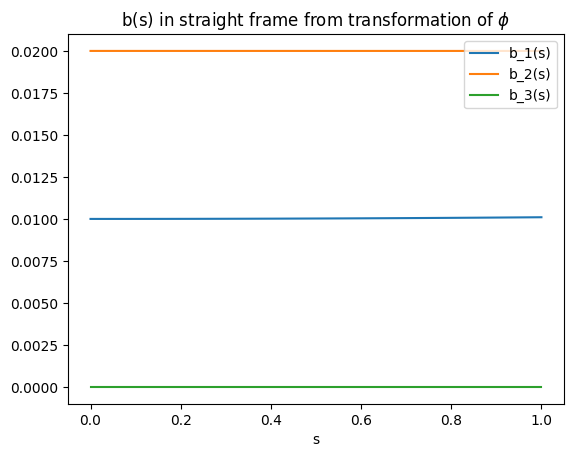

phi0= 0


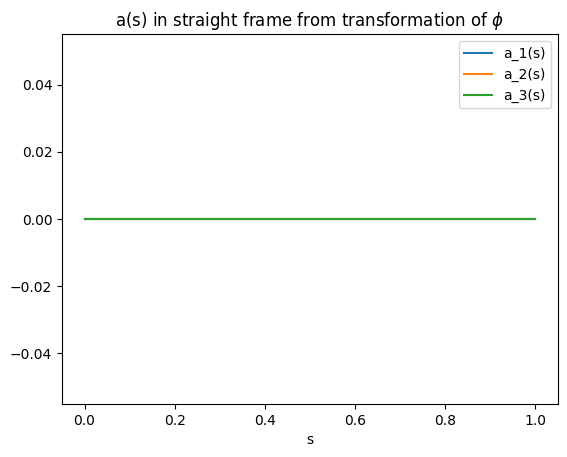

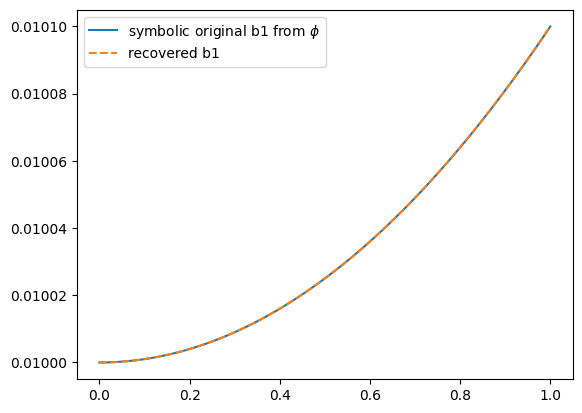

<lambdifygenerated-735>:3: RuntimeWarning: invalid value encountered in sqrt
  return [-(-px - y**6*(2.27514095731229e-13*s**7 - 8.17366319782436e-13*s**6 + 1.18963599826648e-9*s**5 - 2.99555879097974e-9*s**4 + 2.87083605241968e-9*s**3 - 1.29825882963732e-9*s**2 + 2.74144598241305e-10*s + (1/1440)*x**2*(3.44001312745618e-9*s**5 - 8.82755625365031e-9*s**4 + 8.56828460243094e-9*s**3 - 3.8868741572645e-9*s**2 + 8.11639997047797e-10*s - 6.1032986316736e-11) + (1/720)*x*(9.24363887473501e-7*s**5 - 2.32016899909783e-6*s**4 + 2.20786494818468e-6*s**3 - 9.86218887992914e-7*s**2 + 2.04137967981093e-7*s - 1.53817738602903e-8) - 2.13414351583612e-11) - y**4*(-4.7398769944006e-14*s**9 + 2.18937407084581e-13*s**8 - 8.4931498464459e-10*s**7 + 2.99510892128561e-9*s**6 - 4.3059722591861e-9*s**5 + 3.2455411140476e-9*s**4 - 1.37119976659749e-9*s**3 + 3.20118788102787e-10*s**2 + 7.9586474268099e-10*s - 1/48*x**2*(8.19050744632423e-11*s**7 - 2.94251875121677e-10*s**6 + 4.28414230121547e-10*s**5 - 3.239061

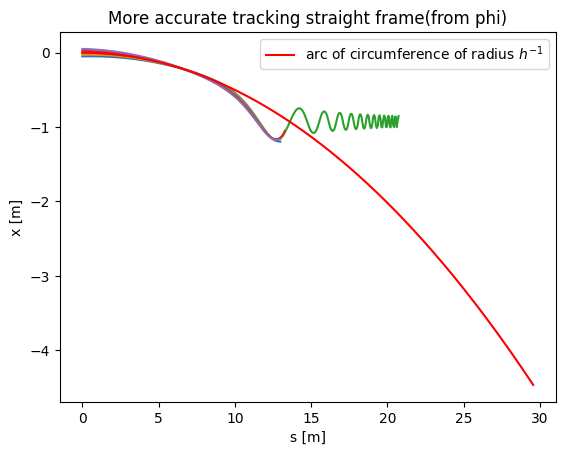

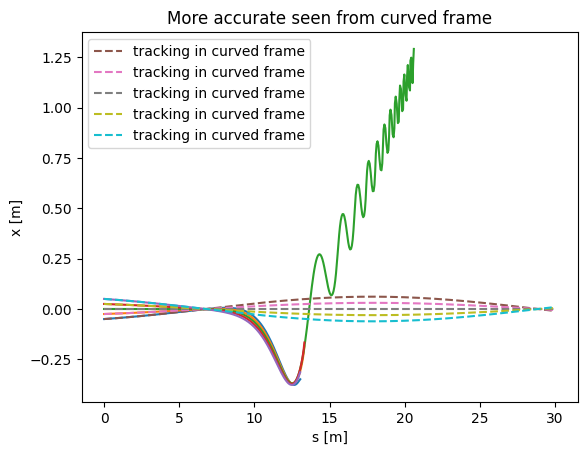

[order 2] particle 0: dx_exit = 3.249e+00 m, RMS_x = 1.423e-01 m
[order 2] particle 1: dx_exit = 3.369e+00 m, RMS_x = 1.389e-01 m
[order 2] particle 2: dx_exit = 3.583e+00 m, RMS_x = 4.194e-01 m
[order 2] particle 3: dx_exit = 3.379e+00 m, RMS_x = 1.242e-01 m
[order 2] particle 4: dx_exit = 3.265e+00 m, RMS_x = 1.164e-01 m
phi1= -4.8e-9*s**6*sqrt(s**2 + x**2 + 200.0*x + 10000.0)/(2.4e-7*s**6 + 7.2e-7*s**4*x**2 + 0.000144*s**4*x - 1.35525271560688e-20*s**4*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 0.0072*s**4 + 7.2e-7*s**2*x**4 + 0.000288*s**2*x**3 - 2.71050543121376e-20*s**2*x**2*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 0.0432*s**2*x**2 - 5.42101086242752e-18*s**2*x*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 2.88*s**2*x - 2.71050543121376e-16*s**2*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 72.0*s**2 + 2.4e-7*x**6 + 0.000144*x**5 - 1.35525271560688e-20*x**4*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 0.036*x**4 - 5.42101086242752e-18*x**3*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 4.8*x**3 - 8.13151629

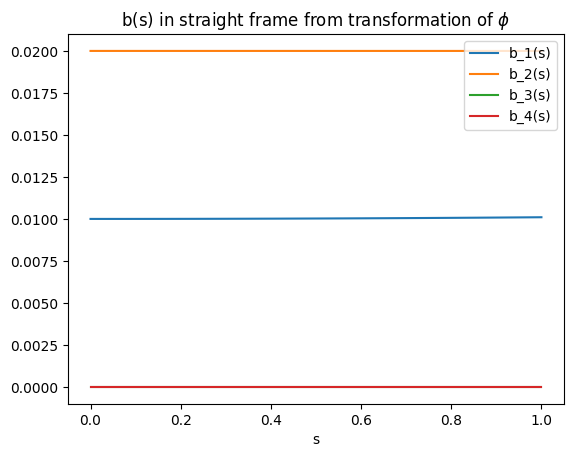

phi0= 0


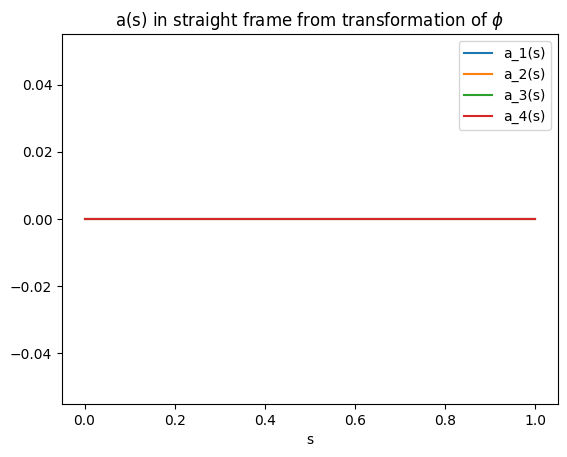

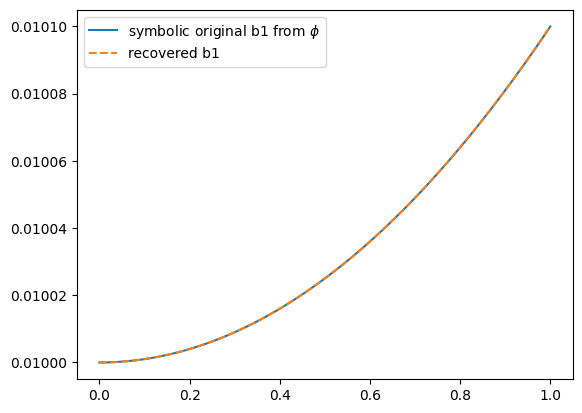

<lambdifygenerated-759>:3: RuntimeWarning: invalid value encountered in sqrt
  return [-(-px - y**6*(2.27514095731229e-13*s**7 - 8.17366319782436e-13*s**6 + 1.18963599826648e-9*s**5 - 2.99555879097974e-9*s**4 + 2.87083605241968e-9*s**3 - 1.29825882963732e-9*s**2 + 2.74144598241305e-10*s + (1/4320)*x**3*(3.737886053201e-10*s**5 - 9.81249279091444e-10*s**4 + 9.82300251484391e-10*s**3 - 4.65142314492506e-10*s**2 + 1.03180793236881e-10*s - 8.47645101090383e-12) + (1/1440)*x**2*(3.44001312745618e-9*s**5 - 8.82755625365031e-9*s**4 + 8.56828460243094e-9*s**3 - 3.8868741572645e-9*s**2 + 8.11639997047797e-10*s - 6.1032986316736e-11) + (1/720)*x*(9.24363887473501e-7*s**5 - 2.32016899909783e-6*s**4 + 2.20786494818468e-6*s**3 - 9.86218887992914e-7*s**2 + 2.04137967981093e-7*s - 1.53817738602903e-8) + (1/360)*x*(8.89972869809762e-12*s**7 - 3.27083093030481e-11*s**6 + 4.91150125742195e-11*s**5 - 3.87618595410422e-11*s**4 + 1.71967988728134e-11*s**3 - 4.23822550545191e-12*s**2 + 4.12742574173549e-12*

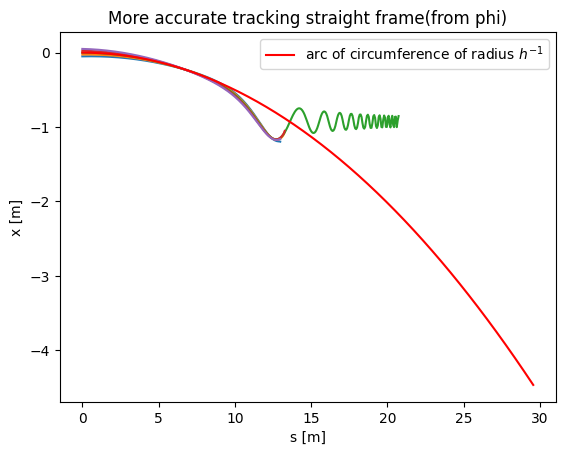

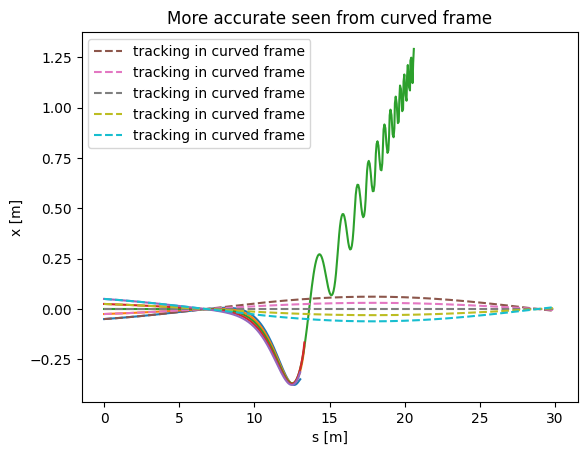

[order 3] particle 0: dx_exit = 3.249e+00 m, RMS_x = 1.423e-01 m
[order 3] particle 1: dx_exit = 3.369e+00 m, RMS_x = 1.389e-01 m
[order 3] particle 2: dx_exit = 3.583e+00 m, RMS_x = 4.194e-01 m
[order 3] particle 3: dx_exit = 3.379e+00 m, RMS_x = 1.242e-01 m
[order 3] particle 4: dx_exit = 3.265e+00 m, RMS_x = 1.164e-01 m
phi1= -4.8e-9*s**6*sqrt(s**2 + x**2 + 200.0*x + 10000.0)/(2.4e-7*s**6 + 7.2e-7*s**4*x**2 + 0.000144*s**4*x - 1.35525271560688e-20*s**4*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 0.0072*s**4 + 7.2e-7*s**2*x**4 + 0.000288*s**2*x**3 - 2.71050543121376e-20*s**2*x**2*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 0.0432*s**2*x**2 - 5.42101086242752e-18*s**2*x*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 2.88*s**2*x - 2.71050543121376e-16*s**2*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 72.0*s**2 + 2.4e-7*x**6 + 0.000144*x**5 - 1.35525271560688e-20*x**4*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 0.036*x**4 - 5.42101086242752e-18*x**3*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 4.8*x**3 - 8.13151629

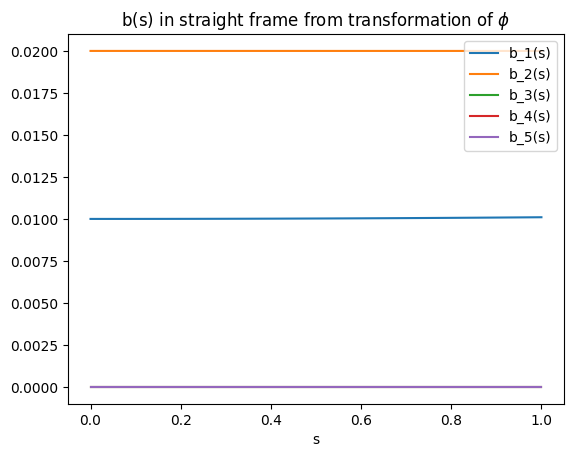

phi0= 0


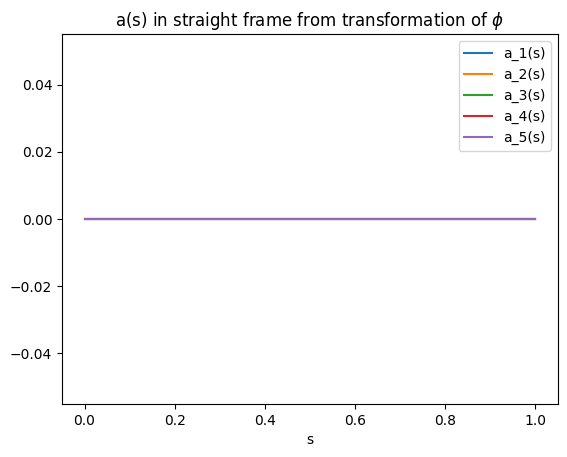

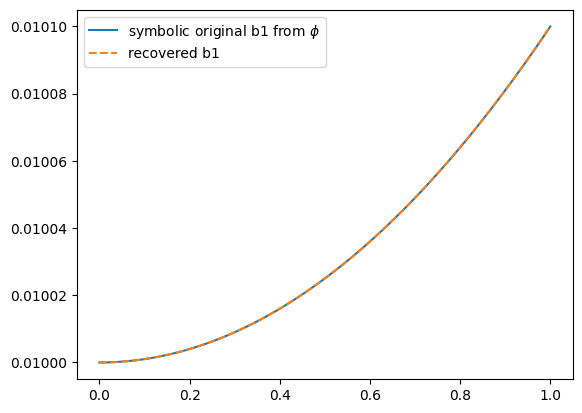

<lambdifygenerated-784>:3: RuntimeWarning: invalid value encountered in sqrt
  return [-(-px - y**8*(1.71977848007505e-16*s**7 - 6.2055489350986e-16*s**6 - 2.55043129629844e-13*s**5 + 6.56116012022313e-13*s**4 - 4.25082210815111e-10*s**3 + 6.42001787553634e-10*s**2 - 3.07609683218853e-10*s - 1/967680*x**4*(-1.94156111286553e-9*s**3 + 3.00249279675811e-9*s**2 - 1.46801582772862e-9*s + 2.24569249690112e-10) - 1/241920*x**3*(7.475772106402e-9*s**3 - 1.17749913490973e-8*s**2 + 5.89380150890634e-9*s - 9.30284628985012e-10) - 1/80640*x**2*(6.88002625491235e-8*s**3 - 1.05930675043804e-7*s**2 + 5.14097076145857e-8*s - 7.773748314529e-9) - 1/26880*x**2*(-9.70780556432764e-11*s**5 + 2.50207733063176e-10*s**4 - 2.44669304621436e-10*s**3 + 1.12284624845056e-10*s**2 - 2.383914906635e-11*s + 1.83603981009422e-12) - 1/40320*x*(1.848727774947e-5*s**3 - 2.78420279891739e-5*s**2 + 1.32471896891081e-5*s - 1.97243777598583e-6) - 1/13440*x*(3.737886053201e-10*s**5 - 9.81249279091444e-10*s**4 + 9.8230025148

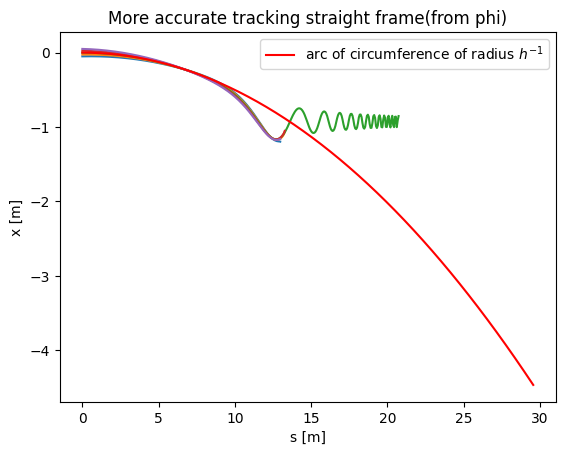

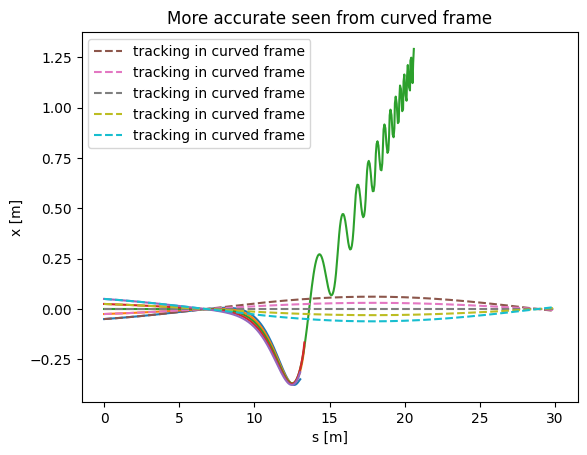

[order 4] particle 0: dx_exit = 3.249e+00 m, RMS_x = 1.423e-01 m
[order 4] particle 1: dx_exit = 3.369e+00 m, RMS_x = 1.389e-01 m
[order 4] particle 2: dx_exit = 3.583e+00 m, RMS_x = 4.194e-01 m
[order 4] particle 3: dx_exit = 3.379e+00 m, RMS_x = 1.242e-01 m
[order 4] particle 4: dx_exit = 3.265e+00 m, RMS_x = 1.164e-01 m
phi1= -4.8e-9*s**6*sqrt(s**2 + x**2 + 200.0*x + 10000.0)/(2.4e-7*s**6 + 7.2e-7*s**4*x**2 + 0.000144*s**4*x - 1.35525271560688e-20*s**4*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 0.0072*s**4 + 7.2e-7*s**2*x**4 + 0.000288*s**2*x**3 - 2.71050543121376e-20*s**2*x**2*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 0.0432*s**2*x**2 - 5.42101086242752e-18*s**2*x*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 2.88*s**2*x - 2.71050543121376e-16*s**2*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 72.0*s**2 + 2.4e-7*x**6 + 0.000144*x**5 - 1.35525271560688e-20*x**4*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 0.036*x**4 - 5.42101086242752e-18*x**3*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 4.8*x**3 - 8.13151629

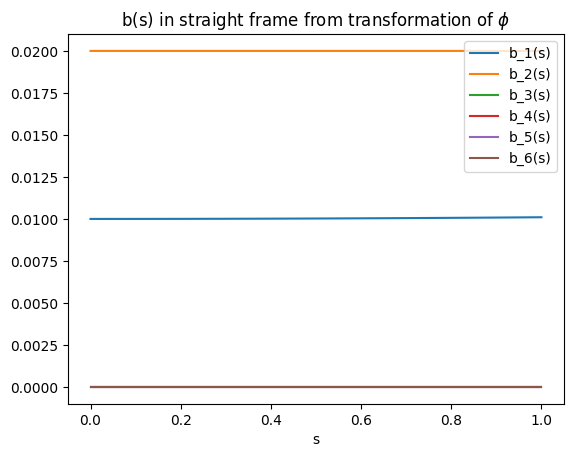

phi0= 0


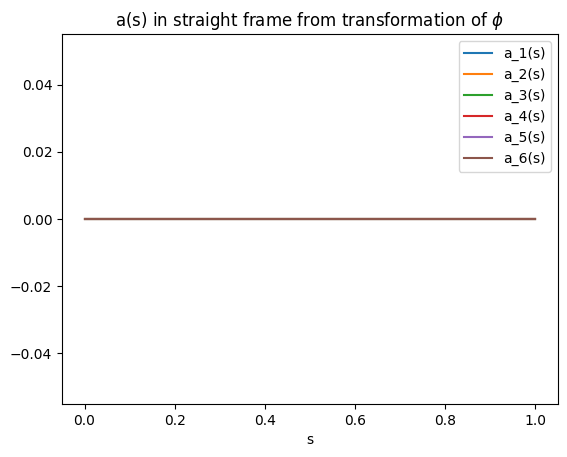

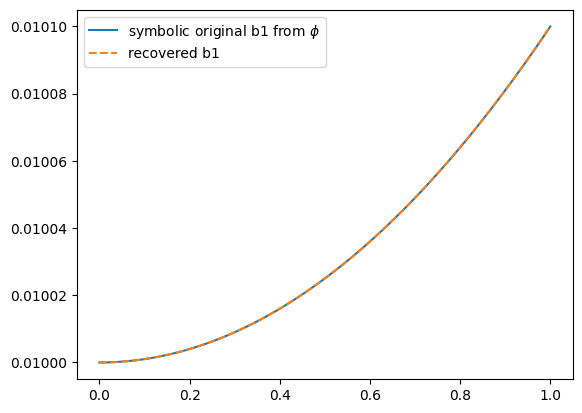

<lambdifygenerated-810>:3: RuntimeWarning: invalid value encountered in sqrt
  return [-(-px - y**8*(1.71977848007505e-16*s**7 - 6.2055489350986e-16*s**6 - 2.55043129629844e-13*s**5 + 6.56116012022313e-13*s**4 - 4.25082210815111e-10*s**3 + 6.42001787553634e-10*s**2 - 3.07609683218853e-10*s - 1/4838400*x**5*(-1.51835619347288e-10*s**3 + 2.5894655246496e-10*s**2 - 1.37043678012545e-10*s + 2.22542143877637e-11) - 1/967680*x**4*(-1.94156111286553e-9*s**3 + 3.00249279675811e-9*s**2 - 1.46801582772862e-9*s + 2.24569249690112e-10) - 1/241920*x**3*(7.475772106402e-9*s**3 - 1.17749913490973e-8*s**2 + 5.89380150890634e-9*s - 9.30284628985012e-10) - 1/80640*x**3*(-7.59178096736441e-12*s**5 + 2.157887937208e-11*s**4 - 2.28406130020908e-11*s**3 + 1.11271071938819e-11*s**2 - 2.45092009851809e-12*s + 1.89675661617895e-13) - 1/80640*x**2*(6.88002625491235e-8*s**3 - 1.05930675043804e-7*s**2 + 5.14097076145857e-8*s - 7.773748314529e-9) - 1/26880*x**2*(-9.70780556432764e-11*s**5 + 2.50207733063176e-10*s*

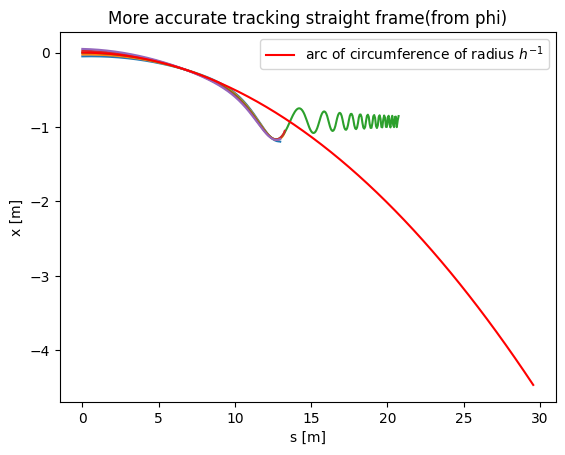

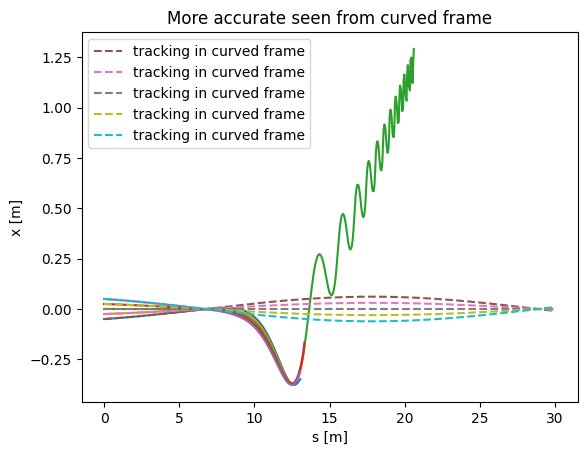

[order 5] particle 0: dx_exit = 3.249e+00 m, RMS_x = 1.423e-01 m
[order 5] particle 1: dx_exit = 3.369e+00 m, RMS_x = 1.389e-01 m
[order 5] particle 2: dx_exit = 3.583e+00 m, RMS_x = 4.194e-01 m
[order 5] particle 3: dx_exit = 3.379e+00 m, RMS_x = 1.242e-01 m
[order 5] particle 4: dx_exit = 3.265e+00 m, RMS_x = 1.164e-01 m
phi1= -4.8e-9*s**6*sqrt(s**2 + x**2 + 200.0*x + 10000.0)/(2.4e-7*s**6 + 7.2e-7*s**4*x**2 + 0.000144*s**4*x - 1.35525271560688e-20*s**4*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 0.0072*s**4 + 7.2e-7*s**2*x**4 + 0.000288*s**2*x**3 - 2.71050543121376e-20*s**2*x**2*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 0.0432*s**2*x**2 - 5.42101086242752e-18*s**2*x*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 2.88*s**2*x - 2.71050543121376e-16*s**2*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 72.0*s**2 + 2.4e-7*x**6 + 0.000144*x**5 - 1.35525271560688e-20*x**4*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 0.036*x**4 - 5.42101086242752e-18*x**3*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 4.8*x**3 - 8.13151629

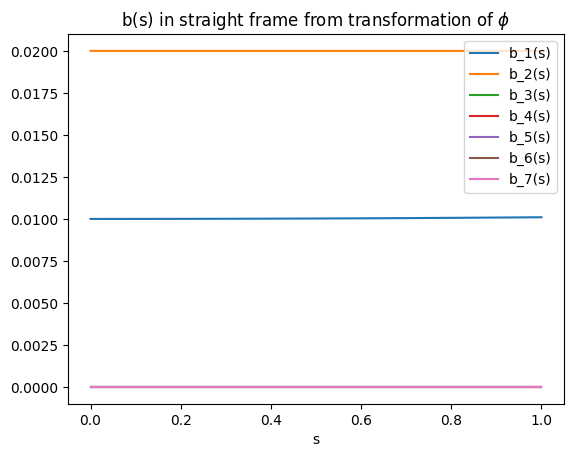

phi0= 0


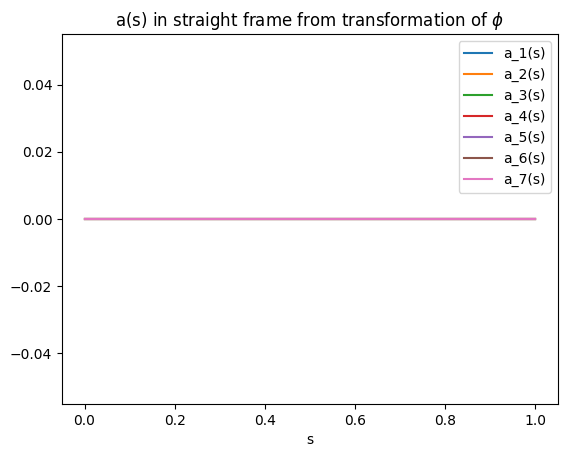

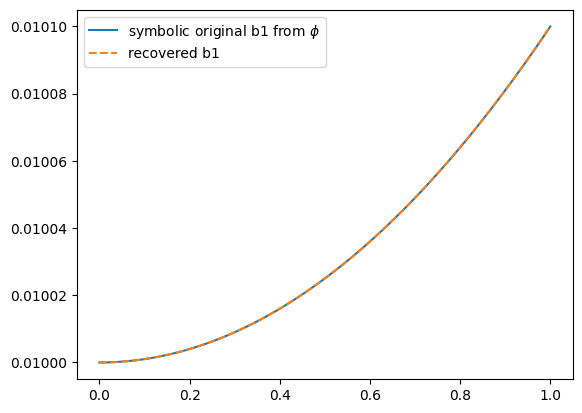

<lambdifygenerated-837>:3: RuntimeWarning: invalid value encountered in sqrt
  return [-(-px - y**10*(1.83280519688338e-20*s**7 - 1.58736723485872e-20*s**6 - 1.60563284941749e-16*s**5 + 4.13798382733813e-16*s**4 + 7.5433422076229e-14*s**3 - 1.16580941279086e-13*s**2 + 2.83529614791677e-11*s + (1/2612736000)*x**6*(8.3801132080475e-11*s - 1.03684287993396e-11) + (1/435456000)*x**5*(5.17893104929921e-10 - 9.1101371608373e-10*s) + (1/87091200)*x**4*(6.00498559351621e-9 - 1.16493666771932e-8*s) + (1/21772800)*x**4*(1.39668553467458e-11*s**3 - 5.18421439966979e-12*s**2 - 5.51143610880841e-12*s + 2.07103731243129e-12) + (1/21772800)*x**3*(4.4854632638412e-8*s - 2.35499826981947e-8) + (1/5443200)*x**3*(-1.51835619347288e-10*s**3 + 2.5894655246496e-10*s**2 - 1.37043678012545e-10*s + 2.22542143877637e-11) + (1/7257600)*x**2*(4.12801575294741e-7*s - 2.11861350087607e-7) + (1/1814400)*x**2*(-1.94156111286553e-9*s**3 + 3.00249279675811e-9*s**2 - 1.46801582772862e-9*s + 2.24569249690112e-10) + (1/12

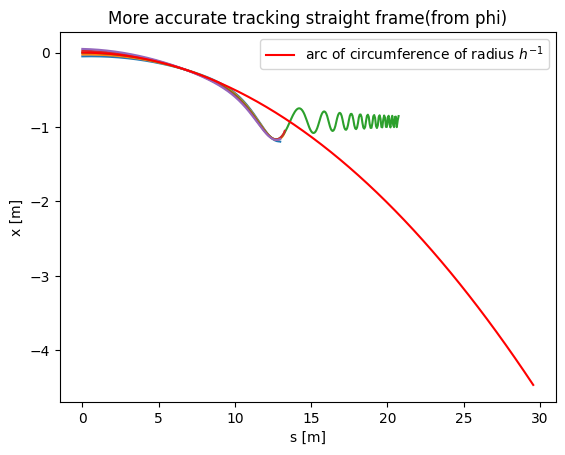

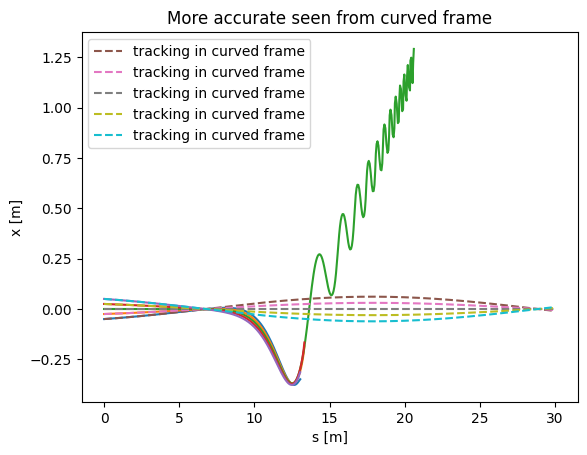

[order 6] particle 0: dx_exit = 3.249e+00 m, RMS_x = 1.423e-01 m
[order 6] particle 1: dx_exit = 3.369e+00 m, RMS_x = 1.389e-01 m
[order 6] particle 2: dx_exit = 3.583e+00 m, RMS_x = 4.194e-01 m
[order 6] particle 3: dx_exit = 3.379e+00 m, RMS_x = 1.242e-01 m
[order 6] particle 4: dx_exit = 3.265e+00 m, RMS_x = 1.164e-01 m
phi1= -4.8e-9*s**6*sqrt(s**2 + x**2 + 200.0*x + 10000.0)/(2.4e-7*s**6 + 7.2e-7*s**4*x**2 + 0.000144*s**4*x - 1.35525271560688e-20*s**4*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 0.0072*s**4 + 7.2e-7*s**2*x**4 + 0.000288*s**2*x**3 - 2.71050543121376e-20*s**2*x**2*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 0.0432*s**2*x**2 - 5.42101086242752e-18*s**2*x*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 2.88*s**2*x - 2.71050543121376e-16*s**2*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 72.0*s**2 + 2.4e-7*x**6 + 0.000144*x**5 - 1.35525271560688e-20*x**4*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 0.036*x**4 - 5.42101086242752e-18*x**3*sqrt(s**2 + x**2 + 200.0*x + 10000.0) + 4.8*x**3 - 8.13151629

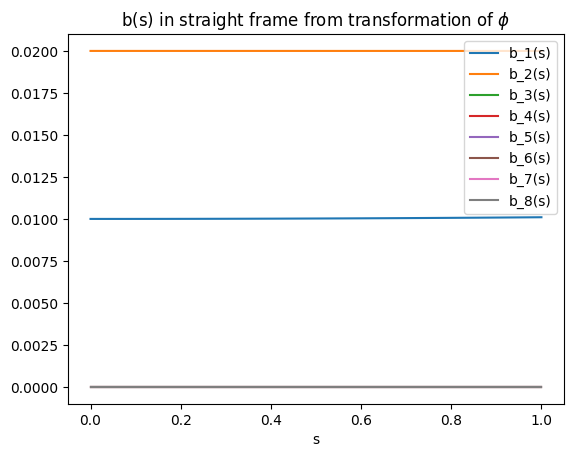

phi0= 0


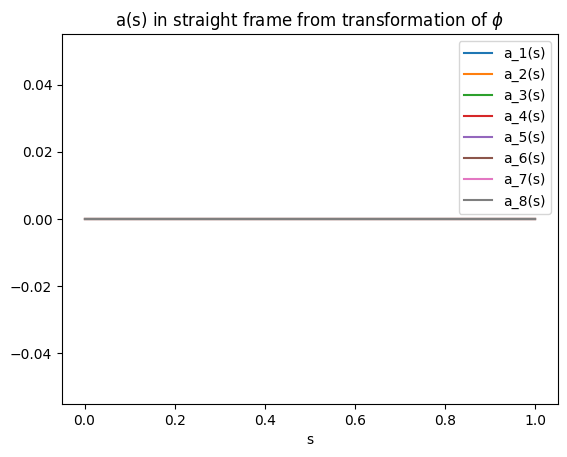

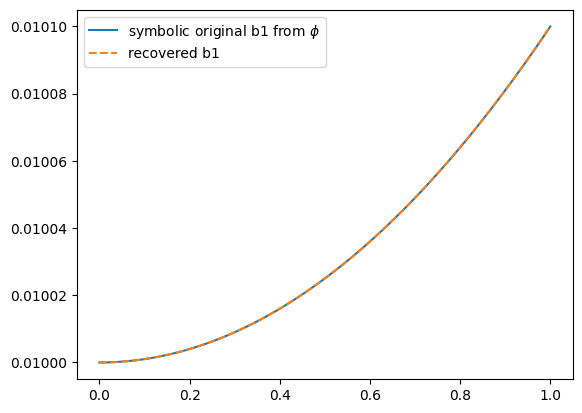

<lambdifygenerated-865>:3: RuntimeWarning: invalid value encountered in sqrt
  return [-(-px - y**10*(1.83280519688338e-20*s**7 - 1.58736723485872e-20*s**6 - 1.60563284941749e-16*s**5 + 4.13798382733813e-16*s**4 + 7.5433422076229e-14*s**3 - 1.16580941279086e-13*s**2 + 2.83529614791677e-11*s + (1/18289152000)*x**7*(4.27034637753443e-11*s - 2.22686049668364e-11) + (1/2612736000)*x**6*(8.3801132080475e-11*s - 1.03684287993396e-11) + (1/435456000)*x**5*(5.17893104929921e-10 - 9.1101371608373e-10*s) + (1/108864000)*x**5*(7.11724396255738e-12*s**3 - 1.11343024834182e-11*s**2 + 5.64520624740414e-12*s - 9.26589286630011e-13) + (1/87091200)*x**4*(6.00498559351621e-9 - 1.16493666771932e-8*s) + (1/21772800)*x**4*(1.39668553467458e-11*s**3 - 5.18421439966979e-12*s**2 - 5.51143610880841e-12*s + 2.07103731243129e-12) + (1/21772800)*x**3*(4.4854632638412e-8*s - 2.35499826981947e-8) + (1/5443200)*x**3*(-1.51835619347288e-10*s**3 + 2.5894655246496e-10*s**2 - 1.37043678012545e-10*s + 2.22542143877637e-1

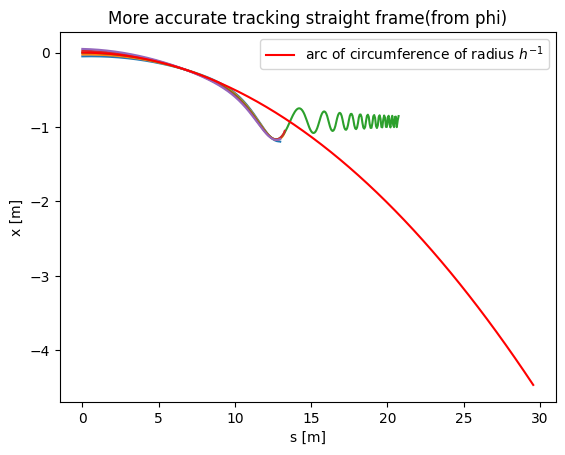

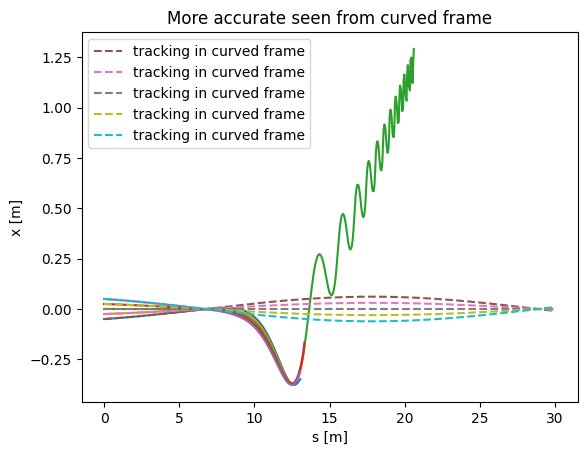

[order 7] particle 0: dx_exit = 3.249e+00 m, RMS_x = 1.423e-01 m
[order 7] particle 1: dx_exit = 3.369e+00 m, RMS_x = 1.389e-01 m
[order 7] particle 2: dx_exit = 3.583e+00 m, RMS_x = 4.194e-01 m
[order 7] particle 3: dx_exit = 3.379e+00 m, RMS_x = 1.242e-01 m
[order 7] particle 4: dx_exit = 3.265e+00 m, RMS_x = 1.164e-01 m


,maxordx,mean_dx_exit,mean_rms_x
0,2,3.368881,0.188242
1,3,3.368970,0.188239
2,4,3.368974,0.188239
3,5,3.368974,0.188239
4,6,3.368974,0.188239
5,7,3.368974,0.188239


In [33]:

orders = [2, 3, 4, 5, 6, 7]
results = []

for ordx in orders:
    maxordx = ordx

    # --------------------------------------------------
    # here the code that depends on maxordx and that
    # regenerates sol_strfromphi and sol_curved
    # --------------------------------------------------
    x, y, s = sp.symbols('x y s', real=True)
    ns=101
    phi_straight_exp = sp.expand(phi_straight)
    phi1 = phi_straight_exp.as_coefficients_dict(y)[y]
    print("phi1=",phi1) 
    ss = np.linspace(0, 1, ns)
    if phi1==0:
        # safety check for when all b_n(s) are zero, one can just create zero arrays with the right shape
    
        b_vals = np.zeros((maxordx+1, ss.size))
    else:
        phi1_series = phi1.series(x, 0, maxordx+1).removeO()
        dct_b = phi1_series.as_coefficients_dict(x)
        # ... then extract a_n(s) as in the previous case
        items_b = sorted(dct_b.items(), key=lambda kv: sp.degree(kv[0], x))

    b_vals = np.zeros((maxordx+1, ss.size))   # include b_0
    if phi1 != 0:
        # 2. Nontrivial phi0: do series in x and extract b_n(s)
        phi1_series = phi1.series(x, 0, maxordx+1).removeO()
        dct_b = phi1_series.as_coefficients_dict(x)

        items_b = sorted(dct_b.items(), key=lambda kv: sp.degree(kv[0], x))

        for k, (xx, vv) in enumerate(items_b):
            if k == 0:
                b_k = -vv                    # b_1(s)
                label = "b_1(s)"
            else:
                b_k = -vv * sp.factorial(k)  # b_k(s)
                label = f"b_{k+1}(s)"

            b_fun = sp.lambdify(s, b_k, 'numpy')
            b_vals[k, :] = b_fun(ss)

            plt.plot(ss, b_vals[k, :], label=label)
    else:
        # 3. phi1 == 0: everything is zero; optionally still plot flat lines
        for k in range(maxordx+1):
            label = f"b_{k+1}(s)"
            # a_vals is already zero
            plt.plot(ss, b_vals[k, :], label=label)

    plt.legend()
    plt.title("b(s) in straight frame from transformation of $\phi$")
    plt.xlabel("s")
    plt.show()
    ############################################
    phi0 = phi_straight.as_coefficients_dict(y)[1]   # phi_0(x, s)
    print("phi0=",phi0)        # you'll see 0 in this case

    if phi0 == 0:
        # safety check for when all a_n(s) are zero, one can just create zero arrays with the right shape
        #ss = np.linspace(0, 1, ns)
        a_vals = np.zeros((maxordx+1, ss.size))
    else:
        phi0_series = phi0.series(x, 0, maxordx+1).removeO()
        dct_a = phi0_series.as_coefficients_dict(x)
        # ... then extract a_n(s) as in the previous case
        items_a = sorted(dct_a.items(), key=lambda kv: sp.degree(kv[0], x))

    a_vals = np.zeros((maxordx+1, ss.size))   # include a_0
    if phi0 != 0:
        # 2. Nontrivial phi0: do series in x and extract a_n(s)
        phi0_series = phi0.series(x, 0, maxordx+1).removeO()
        dct_a = phi0_series.as_coefficients_dict(x)

        items_a = sorted(dct_a.items(), key=lambda kv: sp.degree(kv[0], x))

        for k, (xx, vv) in enumerate(items_a):
            if k == 0:
                a_k = -vv                    # a_0(s)
                label = "a_1(s)"
            else:
                a_k = -vv * sp.factorial(k)  # a_k(s)
                label = f"a_{k+1}(s)"

            a_fun = sp.lambdify(s, a_k, 'numpy')
            a_vals[k, :] = a_fun(ss)

            plt.plot(ss, a_vals[k, :], label=label)
    else:
        # 3. phi0 == 0: everything is zero; optionally still plot flat lines
        for k in range(maxordx+1):
            label = f"a_{k+1}(s)"
            # a_vals is already zero
            plt.plot(ss, a_vals[k, :], label=label)

    plt.legend()
    plt.title("a(s) in straight frame from transformation of $\phi$")
    plt.xlabel("s")
    plt.show()

    b_fromphifit = []# I need symbolic expressions of the coefficients as input
    a_fromphifit = []
    s = sp.symbols('s')
    sstraightarray = ss
    degree = 10

    for arr, dst in [(b_vals.T, b_fromphifit), (a_vals.T, a_fromphifit)]:
        for j in range(arr.shape[1]):
            cheb = np.polynomial.Chebyshev.fit(sstraightarray, arr[:, j], deg=degree, domain=[0, 1])
            poly = cheb.convert(kind=np.polynomial.Polynomial)
            coeffs = poly.coef
            poly_expr = sum(sp.Float(coeffs[i]) * s**i for i in range(len(coeffs)))
            dst.append(sp.expand(poly_expr))   # store SymPy expr, not str


    plt.plot(sstraightarray, b_vals.T[:, 0], label=r"symbolic original b1 from $\phi$")
    # use b_fromphifit (not b_nfit), index 0 = b_1(s)
    b1ofsfromphilambdified = sp.lambdify(s, b_fromphifit[0], modules='numpy')
    plt.plot(sstraightarray, b1ofsfromphilambdified(sstraightarray)*np.ones_like(sstraightarray), '--', label='recovered b1')
    plt.legend()
    plt.show()
    
    Astrfromphi=bpmeth.GeneralVectorPotential(h=0, b=b_fromphifit, a=a_fromphifit, nphi=maxordx+4)#some margin in nphi
    Lstr=np.sin(bending_angle)/h
    Hstrfromphi = bpmeth.Hamiltonian(length=Lstr,h=0, vectp=Astrfromphi)
    p_4 = p0.copy()
    sol_strfromphi = Hstrfromphi.track(p_4, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})
    for ss in sol_strfromphi:
        plt.plot(ss.t, ss.y[0])
    plt.xlabel('s [m]')
    plt.ylabel('x [m]')
    plt.title("More accurate tracking straight frame(from phi)")
    x=np.linspace(0,Lstr,50)
    y= -1/h +np.sqrt(h**-2 -x**2)
    plt.plot(x,y, color='red', label='arc of circumference of radius $h^{-1}$')
    #plt.xlim((0., .98))#because H curved has length 1
    plt.legend()
    plt.show()
    #visualise from the pov of the curved frame
    for ss in sol_strfromphi:
        xc=np.sqrt((ss.y[0]+1/h)**2+ss.t**2)-1/h
        sc=np.arctan(ss.t/(ss.y[0]+1/h))/h
        plt.plot(sc,xc)
    plt.xlabel('s [m]')
    plt.ylabel('x [m]')
    plt.title("More accurate seen from curved frame")
    # x=np.linspace(0,1,50)
    # y= np.zeros(50)
    # plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
    for ss in sol_curved:
        plt.plot(ss.t, ss.y[0],'--',label='tracking in curved frame')
    plt.legend()
    #plt.xlim((0., .98))#because H curved has length 1
    plt.show()
    sbar_fin = Lstr - 0.1
    rho = 1.0 / h
    out = compute_rms_for_order(
        maxordx=maxordx,
        sol_strfromphi=sol_strfromphi,
        sol_curved=sol_curved,
        Lstr=Lstr,
        make_particle_plots=False
    )
    results.append(out)

df_conv = pd.DataFrame(
    {
        "maxordx": [r["maxordx"] for r in results],
        "mean_dx_exit": [r["mean_dx_exit"] for r in results],
        "mean_rms_x": [r["mean_rms_x"] for r in results],
    }
)

display(df_conv)

Convergence for 0.1/m

In [34]:
mean_rms_x_h0_1=df_conv["mean_rms_x"].values #mean_rms_x_h0_1= [8.30498505e-09 1.00448721e-08 1.04151995e-08 1.04253948e-08 1.04256773e-08 1.04256811e-08]
print("mean_rms_x_h0_1=",mean_rms_x_h0_1)
stop

mean_rms_x_h0_1= [0.18824218 0.18823943 0.18823948 0.18823947 0.18823947 0.18823947]


NameError: name 'stop' is not defined

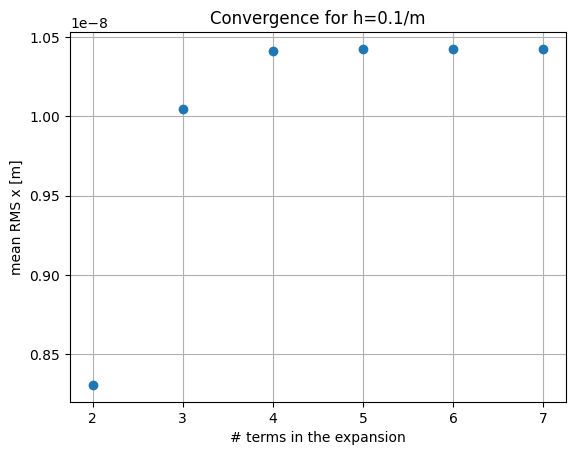

In [ ]:
plt.plot(df_conv["maxordx"], mean_rms_x_h0_1, "o", label=r"$\Delta x_{\mathrm{exit}}$")
plt.title('Convergence for h=0.1/m')
plt.xlabel('# terms in the expansion')
plt.grid(True)
plt.ylabel('mean RMS x [m]')
plt.show()

Convergence for h=10/m

In [ ]:
mean_rms_x_h10=df_conv["mean_rms_x"].values #mean_rms_x_h10= [1.30268505e-10 1.30248410e-10 1.30247907e-10 1.30247896e-10 1.30247895e-10 1.30247895e-10]
print("mean_rms_x_h10=",mean_rms_x_h10)
stop don't rewrite

mean_rms_x_h10= [1.30268505e-10 1.30248410e-10 1.30247907e-10 1.30247896e-10
 1.30247895e-10 1.30247895e-10]


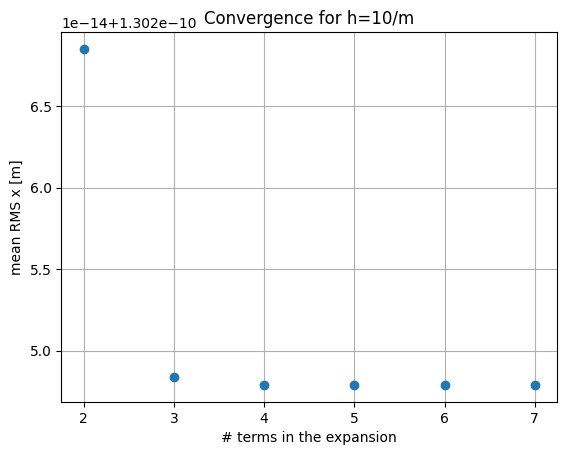

In [ ]:
plt.plot(df_conv["maxordx"], mean_rms_x_h10, "o", label=r"$\Delta x_{\mathrm{exit}}$")
plt.title('Convergence for h=10/m')
plt.xlabel('# terms in the expansion')
plt.grid(True)
plt.ylabel('mean RMS x [m]')
plt.show()

Convergence for h=1.5/m

In [ ]:
mean_rms_x_h1_5=df_conv["mean_rms_x"].values #mean_rms_x_h03= [2.25689749e-10, 2.25634288e-10, 2.25635169e-10 ,2.25635187e-10 ,2.25635188e-10 ,2.25635188e-10]
print("mean_rms_x_h03=",mean_rms_x_h1_5)
stop don't rewrite

mean_rms_x_h03= [2.25689749e-10 2.25634288e-10 2.25635169e-10 2.25635187e-10
 2.25635188e-10 2.25635188e-10]


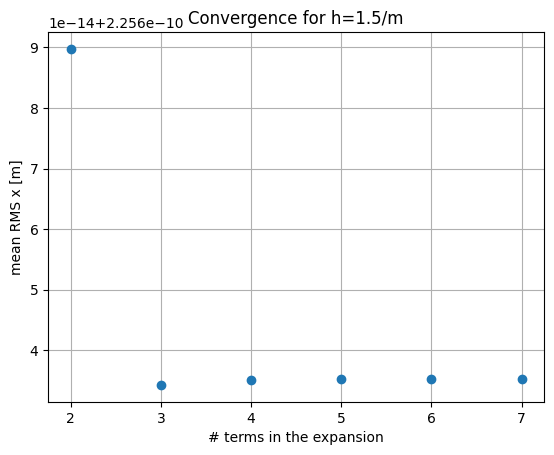

In [ ]:
plt.plot(df_conv["maxordx"], mean_rms_x_h1_5, "o", label=r"$\Delta x_{\mathrm{exit}}$")
plt.title('Convergence for h=1.5/m')
plt.xlabel('# terms in the expansion')
plt.grid(True)
plt.ylabel('mean RMS x [m]')
plt.show()

Convergence for h=0.3/m

In [ ]:
mean_rms_x_h03=df_conv["mean_rms_x"].values #mean_rms_x_h03= [1.35890766e-09, 1.12952751e-09 ,1.12943819e-09 ,1.12944055e-09, 1.12944059e-09 ,1.12944059e-09]
print("mean_rms_x_h03=",mean_rms_x_h03)
stop

mean_rms_x_h03= [1.35890766e-09 1.12952751e-09 1.12943819e-09 1.12944055e-09
 1.12944059e-09 1.12944059e-09]


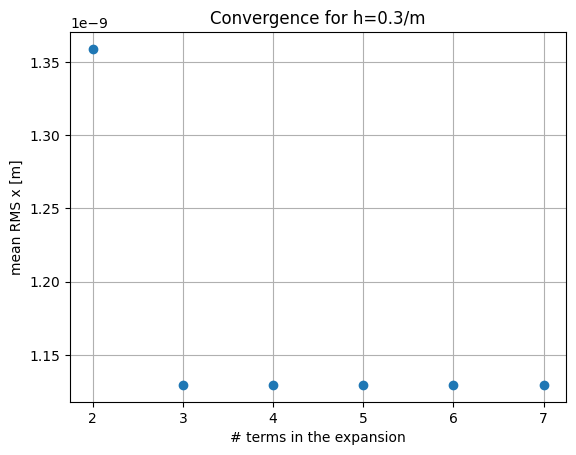

In [ ]:
plt.plot(df_conv["maxordx"], mean_rms_x_h03, "o", label=r"$\Delta x_{\mathrm{exit}}$")
plt.title('Convergence for h=0.3/m')
plt.xlabel('# terms in the expansion')
plt.grid(True)
plt.ylabel('mean RMS x [m]')
plt.show()

In [ ]:
def precompute_phi_coeffs(phi_straight, max_order_global, ss, cheb_degree=10):
    x, y, s = sp.symbols('x y s', real=True)

    phi_straight_exp = sp.expand(phi_straight)
    phi1 = phi_straight_exp.as_coefficients_dict(y)[y]
    phi0 = phi_straight_exp.as_coefficients_dict(y)[1]

    def extract_coeff_list(phi_piece, max_order):
        vals = np.zeros((max_order + 1, ss.size))
        exprs = [sp.Integer(0)] * (max_order + 1)

        if phi_piece == 0:
            return vals, exprs

        series = phi_piece.series(x, 0, max_order + 1).removeO()
        dct = series.as_coefficients_dict(x)

        for n in range(max_order + 1):
            coeff = dct.get(x**n, 0)
            if n == 0:
                expr_n = -coeff
            else:
                expr_n = -coeff * sp.factorial(n)

            exprs[n] = sp.expand(expr_n)
            vals[n, :] = sp.lambdify(s, exprs[n], "numpy")(ss)

        return vals, exprs

    b_vals_all, b_exprs_all = extract_coeff_list(phi1, max_order_global)
    a_vals_all, a_exprs_all = extract_coeff_list(phi0, max_order_global)

    def cheb_fit_exprs(vals):
        out = []
        for j in range(vals.shape[0]):
            cheb = np.polynomial.Chebyshev.fit(ss, vals[j, :], deg=cheb_degree, domain=[0, 1])
            poly = cheb.convert(kind=np.polynomial.Polynomial)
            coeffs = poly.coef
            expr = sum(sp.Float(coeffs[k]) * s**k for k in range(len(coeffs)))
            out.append(sp.expand(expr))
        return out

    b_fit_all = cheb_fit_exprs(b_vals_all)
    a_fit_all = cheb_fit_exprs(a_vals_all)

    return {
        "ss": ss,
        "a_vals_all": a_vals_all,
        "b_vals_all": b_vals_all,
        "a_fit_all": a_fit_all,
        "b_fit_all": b_fit_all,
    }

orders = [2, 3, 4, 5, 6, 7]
max_order_global = max(orders)
ns = 101
ss = np.linspace(0, 1, ns)

pre = precompute_phi_coeffs(phi_straight, max_order_global, ss, cheb_degree=10)

results = []

for ordx in orders:
    b_fromphifit = pre["b_fit_all"][:ordx+1]
    a_fromphifit = pre["a_fit_all"][:ordx+1]

    Astrfromphi = bpmeth.GeneralVectorPotential(
        h=0,
        b=b_fromphifit,
        a=a_fromphifit,
        nphi=ordx + 4
    )

    Lstr = np.sin(bending_angle) / h
    Hstrfromphi = bpmeth.Hamiltonian(length=Lstr, h=0, vectp=Astrfromphi)

    p_4 = p0.copy()
    sol_strfromphi = Hstrfromphi.track(
        p_4,
        return_sol=True,
        ivp_opt={"rtol": 1e-10, "atol": 1e-12}
    )

    out = compute_rms_for_order(
        maxordx=ordx,
        sol_strfromphi=sol_strfromphi,
        sol_curved=sol_curved,
        Lstr=Lstr,
        make_particle_plots=False
    )
    results.append(out)

## Change the quantity of terms in the recovered expression and see how convergence is affected

In [ ]:
maxordx=4
x, y, s = sp.symbols('x y s', real=True)
ns=101
phi_straight_exp = sp.expand(phi_straight)
phi1 = phi_straight_exp.as_coefficients_dict(y)[y]
print("phi1=",phi1) 
ss = np.linspace(0, 1, ns)
if phi1==0:
    # safety check for when all b_n(s) are zero, one can just create zero arrays with the right shape
  
    b_vals = np.zeros((maxordx+1, ss.size))
else:
    phi1_series = phi1.series(x, 0, maxordx+1).removeO()
    dct_b = phi1_series.as_coefficients_dict(x)
    # ... then extract a_n(s) as in the previous case
    items_b = sorted(dct_b.items(), key=lambda kv: sp.degree(kv[0], x))

b_vals = np.zeros((maxordx+1, ss.size))   # include b_0
if phi1 != 0:
    # 2. Nontrivial phi0: do series in x and extract b_n(s)
    phi1_series = phi1.series(x, 0, maxordx+1).removeO()
    dct_b = phi1_series.as_coefficients_dict(x)

    items_b = sorted(dct_b.items(), key=lambda kv: sp.degree(kv[0], x))

    for k, (xx, vv) in enumerate(items_b):
        if k == 0:
            b_k = -vv                    # b_1(s)
            label = "b_1(s)"
        else:
            b_k = -vv * sp.factorial(k)  # b_k(s)
            label = f"b_{k+1}(s)"

        b_fun = sp.lambdify(s, b_k, 'numpy')
        b_vals[k, :] = b_fun(ss)

        plt.plot(ss, b_vals[k, :], label=label)
else:
    # 3. phi1 == 0: everything is zero; optionally still plot flat lines
    for k in range(maxordx+1):
        label = f"b_{k+1}(s)"
        # a_vals is already zero
        plt.plot(ss, b_vals[k, :], label=label)

plt.legend()
plt.title("b(s) in straight frame from transformation of $\phi$")
plt.xlabel("s")
plt.show()
############################################
phi0 = phi_straight.as_coefficients_dict(y)[1]   # phi_0(x, s)
print("phi0=",phi0)        # you'll see 0 in this case

if phi0 == 0:
    # safety check for when all a_n(s) are zero, one can just create zero arrays with the right shape
    #ss = np.linspace(0, 1, ns)
    a_vals = np.zeros((maxordx+1, ss.size))
else:
    phi0_series = phi0.series(x, 0, maxordx+1).removeO()
    dct_a = phi0_series.as_coefficients_dict(x)
    # ... then extract a_n(s) as in the previous case
    items_a = sorted(dct_a.items(), key=lambda kv: sp.degree(kv[0], x))

a_vals = np.zeros((maxordx+1, ss.size))   # include a_0
if phi0 != 0:
    # 2. Nontrivial phi0: do series in x and extract a_n(s)
    phi0_series = phi0.series(x, 0, maxordx+1).removeO()
    dct_a = phi0_series.as_coefficients_dict(x)

    items_a = sorted(dct_a.items(), key=lambda kv: sp.degree(kv[0], x))

    for k, (xx, vv) in enumerate(items_a):
        if k == 0:
            a_k = -vv                    # a_0(s)
            label = "a_1(s)"
        else:
            a_k = -vv * sp.factorial(k)  # a_k(s)
            label = f"a_{k+1}(s)"

        a_fun = sp.lambdify(s, a_k, 'numpy')
        a_vals[k, :] = a_fun(ss)

        plt.plot(ss, a_vals[k, :], label=label)
else:
    # 3. phi0 == 0: everything is zero; optionally still plot flat lines
    for k in range(maxordx+1):
        label = f"a_{k+1}(s)"
        # a_vals is already zero
        plt.plot(ss, a_vals[k, :], label=label)

plt.legend()
plt.title("a(s) in straight frame from transformation of $\phi$")
plt.xlabel("s")
plt.show()

In [ ]:
b_fromphifit = []# I need symbolic expressions of the coefficients as input
a_fromphifit = []
s = sp.symbols('s')
sstraightarray = ss
degree = 10

for arr, dst in [(b_vals.T, b_fromphifit), (a_vals.T, a_fromphifit)]:
    for j in range(arr.shape[1]):
        cheb = np.polynomial.Chebyshev.fit(sstraightarray, arr[:, j], deg=degree, domain=[0, 1])
        poly = cheb.convert(kind=np.polynomial.Polynomial)
        coeffs = poly.coef
        poly_expr = sum(sp.Float(coeffs[i]) * s**i for i in range(len(coeffs)))
        dst.append(sp.expand(poly_expr))   # store SymPy expr, not str


plt.plot(sstraightarray, b_vals.T[:, 0], label=r"symbolic original b1 from $\phi$")
# use b_fromphifit (not b_nfit), index 0 = b_1(s)
b1ofsfromphilambdified = sp.lambdify(s, b_fromphifit[0], modules='numpy')
plt.plot(sstraightarray, b1ofsfromphilambdified(sstraightarray)*np.ones_like(sstraightarray), '--', label='recovered b1')
plt.legend()
plt.show()

In [ ]:
Astrfromphi=bpmeth.GeneralVectorPotential(h=0, b=b_fromphifit, a=a_fromphifit, nphi=maxordx+4)#s dependence of the coefficients
Lstr=np.sin(bending_angle)/h
Hstrfromphi = bpmeth.Hamiltonian(length=Lstr,h=0, vectp=Astrfromphi)
p_4 = p0.copy()
sol_strfromphi = Hstrfromphi.track(p_4, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})
for ss in sol_strfromphi:
    plt.plot(ss.t, ss.y[0])
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("More accurate tracking straight frame(from phi)")
x=np.linspace(0,Lstr,50)
y= -1/h +np.sqrt(h**-2 -x**2)
plt.plot(x,y, color='red', label='arc of circumference of radius $h^{-1}$')
#plt.xlim((0., .98))#because H curved has length 1
plt.legend()
plt.show()
#visualise from the pov of the curved frame
for ss in sol_strfromphi:
    xc=np.sqrt((ss.y[0]+1/h)**2+ss.t**2)-1/h
    sc=np.arctan(ss.t/(ss.y[0]+1/h))/h
    plt.plot(sc,xc)
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("More accurate seen from curved frame")
# x=np.linspace(0,1,50)
# y= np.zeros(50)
# plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
for ss in sol_curved:
    plt.plot(ss.t, ss.y[0],'--',label='tracking in curved frame')
plt.legend()
plt.xlim((0., .98))#because H curved has length 1
plt.show()

In [ ]:
sbar_fin = Lstr-0.1         # chosen exit position in straight frame [m]
rho = 1.0 / h
from scipy.interpolate import PchipInterpolator
dx_exit_list = []      # Δx at exit
rms_x_list = []        # RMS over magnet

for i, (sb, sa) in enumerate(zip(sol_strfromphi, sol_curved)):
    # --- straight-frame tracking ---
    sbar_str = sb.t        # straight longitudinal coordinate \bar{s}
    xbar_str = sb.y[0]     # straight transverse coordinate \bar{x}

    # --- curved-frame tracking, transformed into straight frame ---
    s_curv = sa.t
    x_curv = sa.y[0]

    sbar_from_curv = (rho + x_curv) * np.sin(s_curv / rho)
    xbar_from_curv = -rho + (rho + x_curv) * np.cos(s_curv / rho)

    # --- common sbar range for RMS ---
    sbar_min = max(sbar_str.min(), sbar_from_curv.min())
    sbar_max = min(sbar_str.max(), sbar_from_curv.max())
    if sbar_max <= sbar_min:
        print(f"particle {i}: no overlap in sbar range, skipping")
        continue

    sbar_common = np.linspace(sbar_min, sbar_max, 500)
    print('s_bar_min of particle'+str(i)+'='+str(sbar_min))
    print('s_bar_max of particle'+str(i)+'='+str(sbar_max))

    # interpolate straight tracking onto sbar_common
    xbar_str_common = PchipInterpolator(sbar_str, xbar_str)(sbar_common)

    # interpolate curved→straight tracking onto sbar_common
    idx_curv = np.argsort(sbar_from_curv)
    sbar_sorted = sbar_from_curv[idx_curv]
    xbar_sorted = xbar_from_curv[idx_curv]

    xbar_curv_common = PchipInterpolator(sbar_sorted, xbar_sorted)(sbar_common)

    # --- RMS difference over magnet ---
    dx_all = xbar_str_common - xbar_curv_common
    rms_x = np.sqrt(np.mean(dx_all**2))
    rms_x_list.append(rms_x)

    # --- difference at exit sbar_fin (local diagnostic) ---
    # straight x at exit
    xbar_exit_straight = np.interp(sbar_fin, sbar_str, xbar_str)

    # curved→straight x at the same exit
    # reuse sorted arrays; interpolate in sbar0.10062689441112445
    xbar_exit_from_curv = np.interp(sbar_fin, sbar_sorted, xbar_sorted)

    dx_exit = xbar_exit_straight - xbar_exit_from_curv
    dx_exit_list.append(dx_exit)

    print(
        f"particle {i}: "
        f"dx_exit = {dx_exit:.3e} m, "
        f"RMS_x = {rms_x:.3e} m"
    )

# optional: summary plots
plt.figure()
plt.plot(range(len(dx_exit_list)), dx_exit_list, "o")
plt.xlabel("particle index")
plt.ylabel(r"$\Delta x_{\text{exit}}$ [m]")
plt.title('Difference between x positions at the exit of the magnet predicted by the two trackings using $\phi$ transformation of order '+str(maxordx))
plt.grid(True)

plt.figure()
plt.plot(range(len(rms_x_list)), rms_x_list, "o")
plt.xlabel("particle index")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.title('RMS difference in x along the magnet predicted by the two trackings using $\phi$ transformation of order '+str(maxordx))
plt.grid(True)
plt.show()

print("average final delta x between particles using phi transf. of order "+str(maxordx)+"="+str( np.mean(dx_exit_list)))
print("average RMS x between particles using phi transf. of order "+str(maxordx)+"="+str( np.mean(rms_x_list)))

## The following results were obtained without fixing bending angle and max(hx)

Convergence for h=0.3/m

In [ ]:
orders=np.linspace(2,7,6)
rmsxoforder_h0_3=[6.120518339058754e-10,
                 1.0935479263137754e-10,
                 1.0741192674724452e-10,
                 1.0738539052939527e-10,
                 1.0738459985197033e-10,
                 1.0738457600405461e-10]
plt.plot(orders[:], rmsxoforder_h0_3[:], "o")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.xlabel('maximum order')
plt.yscale('log')
plt.title('Convergence for h=0.3/m')
plt.grid(True)
plt.show()

Convergence for h=10/m

In [ ]:
orders=np.linspace(2,7,6)
rmsxoforder_h10=[0.10062689755970562,
                 0.10062689504815614,
                 0.10062689451058793,
                 0.10062689441112445,
                 0.10062689439921688,
                 0.10062689440105466]
plt.plot(orders[:], rmsxoforder_h10[:], "o")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.xlabel('maximum order')
plt.yscale('log')
plt.title('Convergence for h=10/m')
plt.grid(True)
plt.show()

Convergence for h=0.8/m

In [ ]:
orders=np.linspace(2,7,6)
rmsxoforder_h0_8=[3.5097878738111827e-07,
                  4.260057789088021e-08,
                  4.7221283470399305e-09,
                  6.014730201977918e-10,
                  4.438872264399038e-10,
                  4.4385620706491284e-10]
plt.plot(orders[:], rmsxoforder_h0_8[:], "o")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.xlabel('maximum order')
plt.yscale('log')
plt.title('Convergence for h=0.8/m')
plt.grid(True)
plt.show()

Convergence for h=2/m

In [ ]:
orders=np.linspace(2,7,6)
rmsxoforder_h2=[0.054030865459648095,
                0.05402833628680542,
                0.054027757675104815,
                0.05402767136544838,
                0.05402768121906186,
                0.054027695584995504]
plt.plot(orders[:], rmsxoforder_h2[:], "o")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.xlabel('maximum order')
plt.yscale('log')
plt.title('Convergence for h=2/m')
plt.grid(True)
plt.show()


Convergence rate for h=0.1/m

In [ ]:
orders=np.linspace(2,7,6)
rmsxoforder_h0_1=[2.3904610620580346e-11,
2.376138832911979e-11,
2.376100461722642e-11,
2.3761005058663768e-11,
2.376100453994024e-11,
2.3761004666687316e-11]



plt.plot(orders[:], rmsxoforder_h0_1[:], "o")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.xlabel('maximum order')
plt.yscale('log')
plt.title('Convergence for h=0.1/m')
plt.grid(True)
plt.show()
